In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import cv2
import numpy as np

from src.preprocessing import preprocess_image
from src.segmentation import segmentation_pipeline, kmeans_mask
from src.features import extract_features, extract_sift_features
from src.classification import train_model, predict_image, train_naive_bayes, train_adaboost

In [2]:
def build_dataset(base_dir, method="threshold", feature_type="old"):

    X, y = [], []

    for label_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:

        folder = os.path.join(base_dir, label_name)

        for img_name in os.listdir(folder):

            path = os.path.join(folder, img_name)

            res = preprocess_image(path)
            if res is None:
                continue

            # Segmentation
            if method == "threshold":
                seg = segmentation_pipeline(res["original"], res["grayscale"])
                mask = seg["mask"]
            else:
                mask = kmeans_mask(res["grayscale"])

            # Features
            if feature_type == "old":
                features = extract_features(res["grayscale"], mask)

            elif feature_type == "sift":
                features = extract_sift_features(res["grayscale"], mask)

            elif feature_type == "combined":
                f1 = extract_features(res["grayscale"], mask)
                f2 = extract_sift_features(res["grayscale"], mask)
                features = np.concatenate([f1, f2])

            X.append(features)
            y.append(label)

    return X, y

In [3]:
base_dir = "../data/chest_xray/train"

print("===== THRESHOLD SEGMENTATION =====")

X, y = build_dataset(base_dir, method="threshold", feature_type="old")

model, scaler = train_model(X, y)

===== THRESHOLD SEGMENTATION =====

===== Evaluation =====
Accuracy : 0.9137931034482759
Precision: 0.9501312335958005
Recall   : 0.9329896907216495

Confusion Matrix:
 [[230  38]
 [ 52 724]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       268
           1       0.95      0.93      0.94       776

    accuracy                           0.91      1044
   macro avg       0.88      0.90      0.89      1044
weighted avg       0.92      0.91      0.91      1044



In [4]:
print("===== KMEANS SEGMENTATION =====")

X_k, y_k = build_dataset(base_dir, method="kmeans", feature_type="old")

model_k, scaler_k = train_model(X_k, y_k)

===== KMEANS SEGMENTATION =====

===== Evaluation =====
Accuracy : 0.8467432950191571
Precision: 0.9041994750656168
Recall   : 0.8878865979381443

Confusion Matrix:
 [[195  73]
 [ 87 689]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71       268
           1       0.90      0.89      0.90       776

    accuracy                           0.85      1044
   macro avg       0.80      0.81      0.80      1044
weighted avg       0.85      0.85      0.85      1044



In [6]:
print("===== OLD FEATURES =====")
X_old, y_old = build_dataset(base_dir, "threshold", "old")
train_model(X_old, y_old)

print("===== SIFT FEATURES =====")
X_sift, y_sift = build_dataset(base_dir, "threshold", "sift")
train_model(X_sift, y_sift)

print("===== COMBINED FEATURES =====")
X_comb, y_comb = build_dataset(base_dir, "threshold", "combined")
train_model(X_comb, y_comb)

===== OLD FEATURES =====

===== Evaluation =====
Accuracy : 0.9137931034482759
Precision: 0.9501312335958005
Recall   : 0.9329896907216495

Confusion Matrix:
 [[230  38]
 [ 52 724]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       268
           1       0.95      0.93      0.94       776

    accuracy                           0.91      1044
   macro avg       0.88      0.90      0.89      1044
weighted avg       0.92      0.91      0.91      1044

===== SIFT FEATURES =====

===== Evaluation =====
Accuracy : 0.7959770114942529
Precision: 0.8718626155878467
Recall   : 0.8505154639175257

Confusion Matrix:
 [[171  97]
 [116 660]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.64      0.62       268
           1       0.87      0.85      0.86       776

    accuracy                           0.80      1044
   macro avg       0.73      0.74      0

(RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=200,
                        n_jobs=-1, random_state=42),
 StandardScaler())

In [7]:
print("===== NAIVE BAYES =====")
train_naive_bayes(X_old, y_old)

print("===== ADABOOST =====")
train_adaboost(X_old, y_old)

===== NAIVE BAYES =====

===== NAIVE BAYES =====
Accuracy : 0.8400383141762452
Precision: 0.9578947368421052
Recall   : 0.8208762886597938

Confusion Matrix:
 [[240  28]
 [139 637]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.90      0.74       268
           1       0.96      0.82      0.88       776

    accuracy                           0.84      1044
   macro avg       0.80      0.86      0.81      1044
weighted avg       0.87      0.84      0.85      1044

===== ADABOOST =====

===== ADABOOST =====
Accuracy : 0.8831417624521073
Precision: 0.9442934782608695
Recall   : 0.895618556701031

Confusion Matrix:
 [[227  41]
 [ 81 695]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.85      0.79       268
           1       0.94      0.90      0.92       776

    accuracy                           0.88      1044
   macro avg       0.84      0.87      0.85     

(AdaBoostClassifier(learning_rate=0.8, n_estimators=150, random_state=42),
 StandardScaler())

In [13]:
import matplotlib.pyplot as plt

def show_pipeline(path):

    res = preprocess_image(path)
    gray = res["grayscale"]

    seg = segmentation_pipeline(res["original"], gray)
    k_mask = kmeans_mask(gray)
    
    plt.figure(figsize=(12,6))

    plt.subplot(2,3,1)
    plt.imshow(res["original"])
    plt.title("Original")

    plt.subplot(2,3,2)
    plt.imshow(gray, cmap="gray")
    plt.title("Gray")

    plt.subplot(2,3,3)
    plt.imshow(res["gaussian"], cmap="gray")
    plt.title("Gaussian")

    plt.subplot(2,3,4)
    plt.imshow(seg["thresholded"], cmap="gray")
    plt.title("Threshold Raw")

    plt.subplot(2,3,5)
    plt.imshow(seg["mask"], cmap="gray")
    plt.title("Final Mask")

    plt.subplot(2,3,6)
    plt.imshow(k_mask, cmap="gray")
    plt.title("KMeans")
plt.show()
    

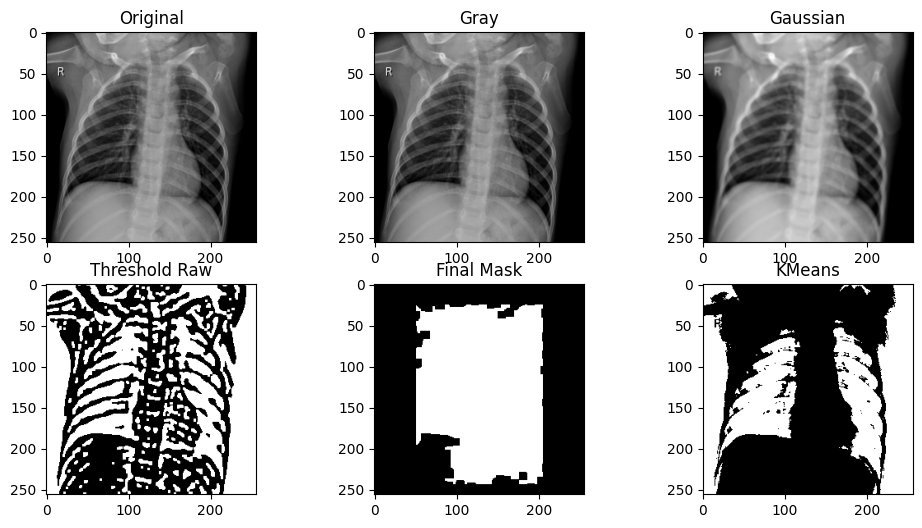

In [14]:
test_img = "../data/chest_xray/val/NORMAL/NORMAL2-IM-1442-0001.jpeg"

show_pipeline(test_img)

In [10]:
print("===== FINAL PREDICTION =====")

result = predict_image(
    model,
    scaler,
    test_img,
    preprocess_image,
    segmentation_pipeline,
    extract_features
)

print("Prediction:", result)

===== FINAL PREDICTION =====
Prediction: Normal


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(model, scaler, X, y, name):
    
    # Split نفس اللي انت استخدمته
    from sklearn.model_selection import train_test_split
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3)
    }


# =========================
# Import models
# =========================
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

results = []

# =========================
# Random Forest
# =========================
results.append(evaluate_model(
    RandomForestClassifier(n_estimators=200, max_depth=15),
    StandardScaler(),
    X_old, y_old,
    "Random Forest"
))

# =========================
# AdaBoost
# =========================
results.append(evaluate_model(
    AdaBoostClassifier(n_estimators=100),
    StandardScaler(),
    X_old, y_old,
    "AdaBoost"
))

# =========================
# Naive Bayes
# =========================
results.append(evaluate_model(
    GaussianNB(),
    StandardScaler(),
    X_old, y_old,
    "Naive Bayes"
))


# =========================
# DataFrame عرض احترافي
# =========================
df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.916,0.949,0.937,0.943
1,AdaBoost,0.877,0.948,0.884,0.915
2,Naive Bayes,0.840,0.958,0.821,0.884
